In [20]:
import kan, torch
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from kan import ex_round

def normalize(x):  # min-max scaling
    return (x - x.min()) / (x.max() - x.min())

def denormalize(x, x_min, x_max):  # min-max unscaling
    return x * (x_max - x_min) + x_min

def train_model(expmnt, all_time, all_PCD, all_volt, all_bias, all_load, diode_types, 
                time_mx_mn, PCD_mx_mn, volt_mx_mn, train_losses, test_losses, train_ratio):
    
    # initialize for the number of possible diodes
    diode1 = []  # SMAJ
    diode2 = []  # MMSZ
    diode3 = []  # CSD
    diode4 = []  # NJ
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    #print(device)

    kan_inputs = len(diode_types) + 4 # time, PCD, bias, load, and one-hot diode type
    # initialize KAN
    model = kan.KAN(width=[kan_inputs, 8, 1], grid=16, k=3, seed=1, device=str(device))

    # declare variables used elsewhere in program.
    expmnt_size = []

    for exp_num in expmnt:

        # collect data from dataset
        file_name = f"TestData\\LFXR_Lovejoy_Sept2021_{exp_num}.csv"
        df_train = pd.read_csv(file_name, usecols=[0,1,3])

        df_start_stop = pd.read_csv("start_stop_pts.csv")
        expmnt_row = exp_num - 27271   # the first experiment is on row 1
        volt_start = int(df_start_stop['volt_start'].iloc[expmnt_row])
        volt_stop = int(df_start_stop['volt_stop'].iloc[expmnt_row])
        rad_start = int(df_start_stop['rad_start'].iloc[expmnt_row])
        rad_stop = int(df_start_stop['rad_stop'].iloc[expmnt_row])

        expmnt_size.append(volt_stop - volt_start)

        bias = float(df_start_stop['bias'].iloc[expmnt_row])
        load = float(df_start_stop['load'].iloc[expmnt_row])

        
        diode_onehot = [0,0,0,0]
        diode_type = df_start_stop['diode_type'].iloc[expmnt_row]
        diode_index = diode_types.index(diode_type)
        diode_onehot[diode_index] = 1
        
        #print(volt_start, volt_stop, rad_start, rad_stop)

        time = df_train['time1'].iloc[volt_start:volt_stop].to_numpy(dtype = np.float32)
        # Make time in microseconds
        time = time * 1e6
        time = time - time.min()  # shift time to start at 0
        time_mx_mn[0].append(time.max())
        time_mx_mn[1].append(time.min())    
        time = normalize(time)  # normalize time to [0,1]

        PCD = df_train['PCD3_B'].iloc[rad_start:rad_stop].to_numpy(dtype = np.float32)
        PCD_mx_mn[0].append(PCD.max())
        PCD_mx_mn[1].append(PCD.min())  
        PCD = normalize(PCD)  # normalize PCD to [0,1]

        # output voltage
        volt = df_train['Diode'].iloc[volt_start:volt_stop].to_numpy(dtype = np.float32).reshape(-1,1)
        volt_mx_mn[0].append(volt.max())
        volt_mx_mn[1].append(volt.min())
        volt = normalize(volt)  # normalize voltage to [0,1]

        all_time.append(time)
        all_PCD.append(PCD)
        all_volt.append(volt)
        all_bias.append(np.full_like(time, bias))
        all_load.append(np.full_like(time, np.log10(load))) # use logarithmic scale for load to prevent NANs.
        
        # needs one array per diode type, with 1s for the current diode and 0s for the others. Will be concatenated later.
        diode1.append(np.full_like(time, diode_onehot[0]))
        diode2.append(np.full_like(time, diode_onehot[1]))
        diode3.append(np.full_like(time, diode_onehot[2]))
        diode4.append(np.full_like(time, diode_onehot[3]))

    all_time = np.concatenate(all_time)
    all_PCD = np.concatenate(all_PCD)
    all_volt = np.concatenate(all_volt)
    all_bias = np.concatenate(all_bias)
    all_load = np.concatenate(all_load)
    diode1  = np.concatenate(diode1)
    diode2  = np.concatenate(diode2)
    diode3  = np.concatenate(diode3)
    diode4  = np.concatenate(diode4)

    # Normalize the data
    n_time = normalize(all_time)  # normalize time to [0,1]
    n_PCD = normalize(all_PCD)  # normalize PCD to [0,1]
    # normalize voltage to [0,1]
    n_volt = normalize(all_volt)  # normalize voltage to [0,1]

    n_bias = all_bias
    n_load = all_load
    # Diode will be one-hot encoded 

    # Make input matrix
    X = np.column_stack((n_time, n_PCD, n_bias, n_load, diode1, diode2, diode3, diode4))  # shape (num_samples, 8)


    #pull training points from the data
    np.random.seed(None)
    # need to get certain number of points from each experiment, so we don't just pull the first 70% of the data
    slice_idx = 0
    test_indices = np.array([], dtype=int)
    for i in range(len(expmnt)):
        slice_idx += expmnt_size[i]
        exp_indices = np.arange(slice_idx - expmnt_size[i], slice_idx)
        exp_test_indices = np.random.choice(exp_indices, round(expmnt_size[i] * (1 - train_ratio)), replace=False)
        test_indices = np.concatenate((test_indices, exp_test_indices))

    X_test = X[test_indices]
    n_volt_test = n_volt[test_indices] # Correct Answers

    #pull the rest for testing
    train_indices = np.setdiff1d(np.arange(X.shape[0]), test_indices)
    X_train = X[train_indices]
    n_volt_train = n_volt[train_indices]

    dataset = {
        "train_input": torch.from_numpy(X_train).to(device),
        "train_label": torch.from_numpy(n_volt_train).to(device),
        "test_input":  torch.from_numpy(X_test).to(device),
        "test_label":  torch.from_numpy(n_volt_test).to(device),
    }

    print(X.shape, n_volt.shape)
    

    results = model.fit(dataset,
            opt="LBFGS",
            steps=100,
            lr=0.04,
            update_grid=False,
            start_grid_update_step= 40,
            lamb=0.0002,        # master scale — tune this first
            lamb_l1=0.0,      # high — you want to prune weak connections
            lamb_entropy=0.0, # high — encourages interpretable simple functions
            lamb_coef=0.0,    # usually redundant if l1 is active
            lamb_coefdiff=0.0) # smooth splines — important for noisy data)
    train_losses += results['train_loss']
    test_losses += results['test_loss']

    # # plot the two losses
    # plt.plot(train_losses)
    # plt.plot(test_losses)
    # plt.legend(['train', 'test'])
    # plt.ylabel('RMSE')
    # plt.xlabel('step')
    # plt.yscale('log')
    # plt.show()

    return model, dataset, expmnt_size





In [21]:
def plot_results(model, dataset, time_mx_mn, PCD_mx_mn, volt_mx_mn, expmnt, expmnt_size, train_ratio):    

    t = dataset["test_input"][:, 0]   # assumes column 0 is time
    r = dataset["test_input"][:, 1]   # assumes column 1 is radiation
    v = dataset["test_label"]         # voltage target

    with torch.no_grad():
        v_pred = model(dataset["test_input"])


    # need to get certain number of points from each experiment, so we don't just pull the first 70% of the data
    test_results_idx = 0
    # test_indice are already defined
    for i in range(len(expmnt)):
        # Get the number of test points for this experiment
        num_test_pts = round(expmnt_size[i] * (1 - train_ratio))

        # Extract the relevant portion of the data for this experiment
        t_np = t.detach().cpu().numpy()[test_results_idx:test_results_idx + num_test_pts]
        r_np = r.detach().cpu().numpy()[test_results_idx:test_results_idx + num_test_pts]
        v_np = v.detach().cpu().numpy()[test_results_idx:test_results_idx + num_test_pts]
        v_pred_np = v_pred.detach().cpu().numpy()[test_results_idx:test_results_idx + num_test_pts]

        # Denormalize the data for plotting ; xxxx_mx_min[0] is max, xxxx_mx_mn[1] is min
        t_np = denormalize(t_np, time_mx_mn[1][i], time_mx_mn[0][i])  # unnormalize time
        r_np = denormalize(r_np, PCD_mx_mn[1][i], PCD_mx_mn[0][i])  # unnormalize PCD
        v_np = denormalize(v_np, volt_mx_mn[1][i], volt_mx_mn[0][i])  # unnormalize voltage
        v_pred_np = denormalize(v_pred_np, volt_mx_mn[1][i], volt_mx_mn[0][i])  # unnormalize voltage

        test_results_idx += num_test_pts

        arr = np.column_stack((t_np / 1e6, r_np))
        sorted_arr = arr[np.argsort(arr[:, 0])]
        # Define folder and file path
        folder = "pulse_text_files"
        os.makedirs(folder, exist_ok=True)  # Creates folder if it doesn't exist

        file_path = os.path.join(folder, f"pulse_{expmnt[i]}.txt")

        # # Save array to .txt file
        # np.savetxt(
        #     file_path,
        #     sorted_arr,
        #     fmt="%.9e",          # Integer format (use "%.4f" for floats)
        #     delimiter=" ",     # Whitespace delimiter
        #     )

        plt.figure()
        plt.scatter(t_np, v_np, s=20, label="voltage (true)")
        plt.scatter(t_np, v_pred_np, s=7, label="voltage (pred)")
        #plt.scatter(t_np, r_np, s=7, label="radiation")
        plt.xlabel("time (us)")
        plt.ylabel("voltage (V)")
        plt.title(f"Experiment {expmnt[i]}")
        plt.legend()
        plt.show()

# # Set nodes with functions
# kan.add_symbolic('exp_neg', lambda x: torch.exp(-x))
# kan.add_symbolic('sigmoid', lambda x: torch.sigmoid(x))
# kan.add_symbolic('gaussian', lambda x: torch.exp(-x**2))

# lib = [
#     'x',
#     'exp',
#     'exp_neg',
#     'log',
#     'sqrt',
#     'tanh',
#     'sigmoid',
#     'gaussian',
#     'sin',
#     'abs',
# ]

# model = model.prune()
# model.auto_symbolic(lib=lib, r2_threshold=0.88)
# formula = model.symbolic_formula()[0][0]
# kan.ex_round(formula, 4)


Processing experiment 27278...
checkpoint directory created: ./model
saving model version 0.0
(600, 8) (600, 1)


| train_loss: 5.64e-03 | test_loss: 6.01e-03 | reg: 0.00e+00 | : 100%|█| 100/100 [00:44<00:00,  2.23

saving model version 0.1


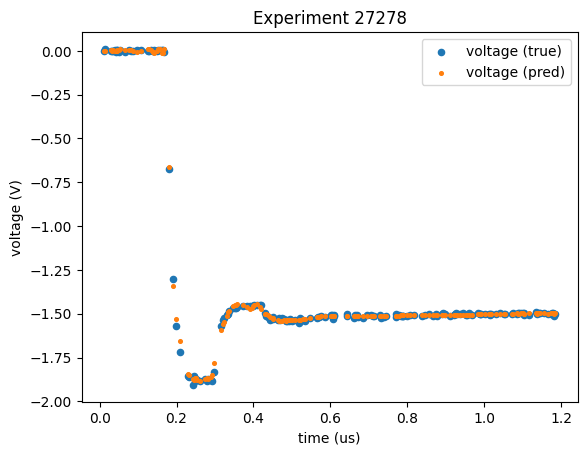

Processing experiment 27279...
checkpoint directory created: ./model
saving model version 0.0
(600, 8) (600, 1)


| train_loss: 1.76e-02 | test_loss: 1.90e-02 | reg: 0.00e+00 | : 100%|█| 100/100 [00:42<00:00,  2.34

saving model version 0.1


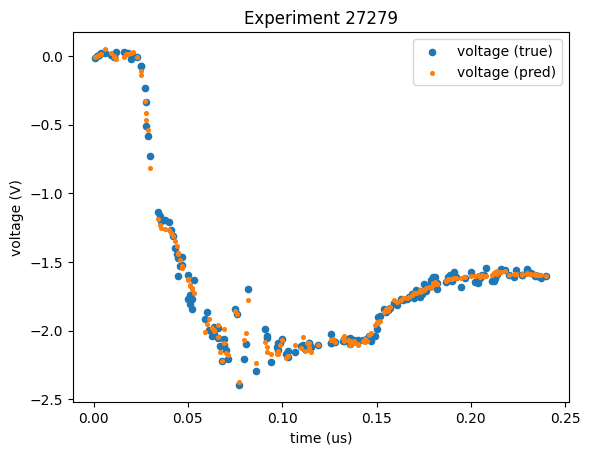

Final test losses for each experiment:  [0.6, 1.9]


In [ ]:
train_these = [27278,27279]
test_these = [27282,27284]
expmnt = [[27271],[27271]]  # experiment number(s) to use for training and testing
final_test_losses = []
for i in test_these:
    print(f"Processing experiment {i}...")
    #reset variables
    all_time = []
    time_mx_mn = [[],[]]
    all_PCD = []
    PCD_mx_mn = [[],[]]
    all_volt = []
    volt_mx_mn = [[],[]]
    all_bias = []
    all_load = []
    # Use one-hot encoding for diode type (0,1,2)
    diode_types = ["SMAJ", "MMSZ", "CSD", "NJ"] # update train_model if this changes

    train_losses = []
    test_losses = []
    train_ratio = 0.7  # Use 70% of the data for training
    if i in [27277, 27292, 27293, 27306]: 
        pass
    else: 
        expmnt[0][:] = train_these[:]
        expmnt[1][0] = i

        M1, data1, expmnt_size = train_model(expmnt, all_time, all_PCD, all_volt, all_bias, all_load, diode_types, time_mx_mn, PCD_mx_mn, volt_mx_mn, train_losses, test_losses, train_ratio)
        final_test_losses.append(round(float(test_losses[-1])*100,3)) # already in percentage form and rounded

        plot_results(M1, data1, time_mx_mn, PCD_mx_mn, volt_mx_mn, expmnt, expmnt_size, train_ratio)
print("Final test losses for each experiment: ", final_test_losses)